# Notebook 02: Save & Load Models

**Module**: Production & Deployment  
**Level**: Beginner  
**Duration**: 30-45 minutes

## Learning Objectives

By the end of this notebook, you will be able to:

1. Save any PanelBox model to disk using `save()`
2. Load models in a new session using `load()` and `load_model()`
3. Understand pickle vs JSON serialization trade-offs
4. Verify loaded models retain predict capability
5. Export model coefficients for external systems (JSON, dict)

## Prerequisites

- Familiarity with panel data concepts (entities, time periods)
- Completed Notebook 01 (Predict Fundamentals) or equivalent knowledge

---
## Setup

In [1]:
import json

# Helpers
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from panelbox import load_model
from panelbox.core.results import PanelResults
from panelbox.gmm import DifferenceGMM
from panelbox.gmm.results import GMMResults

# PanelBox imports
from panelbox.models.static.pooled_ols import PooledOLS

sys.path.insert(0, str(Path("..")))
from utils.visualization_helpers import set_production_style

# Configuration
np.random.seed(42)
warnings.filterwarnings("ignore")
set_production_style()

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "outputs" / "models"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# Load datasets
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_new_firms = pd.read_csv(DATA_DIR / "new_firms.csv")
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

print(
    f"Firm panel:    {df_firms.shape[0]:,} rows  ({df_firms['firm_id'].nunique()} firms x {df_firms['year'].nunique()} years)"
)
print(f"New firms:     {df_new_firms.shape[0]:,} rows  ({df_new_firms['firm_id'].nunique()} firms)")
print(
    f"Bank LGD:      {df_lgd.shape[0]:,} rows  ({df_lgd['contract_id'].nunique()} contracts x {df_lgd['month'].nunique()} months)"
)
print(
    f"New bank data: {df_new_bank.shape[0]:,} rows  ({df_new_bank['contract_id'].nunique()} contracts)"
)

Firm panel:    2,000 rows  (100 firms x 20 years)
New firms:     100 rows  (20 firms)
Bank LGD:      3,000 rows  (200 contracts x 15 months)
New bank data: 150 rows  (50 contracts)


---
## 1. Why Persist Models?

In a production workflow, you don't re-estimate a model every time you need a prediction. Instead, you:

1. **Estimate once** on historical data (can take minutes for GMM with many instruments)
2. **Save** the fitted model to disk
3. **Load** the model in production to generate predictions on demand

Why does this matter?

| Reason | Detail |
|--------|--------|
| **Speed** | Loading a saved model is instantaneous; re-estimating is not |
| **Reproducibility** | A saved model gives identical predictions every time |
| **Collaboration** | Share fitted models across team members |
| **Audit trail** | Keep historical model versions for regulatory compliance |
| **Deployment** | Production servers load pre-fitted models, not training code |

PanelBox provides three levels of persistence:

1. **`results.save()`** / **`Results.load()`** — class-specific save/load
2. **`load_model()`** — universal loader (auto-detects model type)
3. **`to_dict()` / `to_json()`** — export coefficients for external systems

---
## 2. PanelResults — Save & Load

Let's start with a Pooled OLS model. We'll estimate it, save it to disk in both pickle and JSON formats, then load it back and verify everything is preserved.

In [3]:
# Estimate Pooled OLS
model_ols = PooledOLS(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results_ols = model_ols.fit()
print(results_ols.summary())

                        Pooled OLS Estimation Results                         
Formula: investment ~ value + capital + sales
Model:   Pooled OLS
------------------------------------------------------------------------------
No. Observations:               2,000
No. Entities:                     100
No. Time Periods:                  20
Degrees of Freedom:             1,996
R-squared:                     0.3273
Adj. R-squared:                0.3263
R-squared (overall):           0.3273
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept           -0.5074      0.1370  -3.704  0.0002   -0.7761   -0.2387 ***
value                0.2990      0.0129  23.213  0.0000    0.2738    0.3243 ***
capital              0.2773      0.0218  12.718  0.0000    0.2345    0.3201 ***
sales                0.1674      0.0105  15.995  0.0000    0.1469    0.

### 2.1 Save as Pickle (recommended)

Pickle format preserves the **complete Python object** — all coefficients, covariance matrices, residuals, fitted values, and even the predict() method. This is the recommended format for production.

In [4]:
# Save as pickle
pkl_path = MODELS_DIR / "pooled_ols_v1.pkl"
results_ols.save(str(pkl_path))

file_size = pkl_path.stat().st_size
print(f"Saved to: {pkl_path}")
print(f"File size: {file_size:,} bytes ({file_size / 1024:.1f} KB)")

Saved to: ../outputs/models/pooled_ols_v1.pkl
File size: 254,752 bytes (248.8 KB)


### 2.2 Save as JSON

JSON format is human-readable and useful for sharing coefficients with external systems. However, it does **not** preserve the full object (no predict() method, limited precision).

In [5]:
# Save as JSON
json_path = MODELS_DIR / "pooled_ols_v1.json"
results_ols.save(str(json_path), format="json")

file_size_json = json_path.stat().st_size
print(f"Saved to: {json_path}")
print(f"File size: {file_size_json:,} bytes ({file_size_json / 1024:.1f} KB)")
print()

# Peek at the JSON content
with open(json_path) as f:
    content = json.load(f)
print("JSON keys:", list(content.keys()))
print("Params:", content.get("params", {}))

Saved to: ../outputs/models/pooled_ols_v1.json
File size: 98,194 bytes (95.9 KB)

JSON keys: ['params', 'std_errors', 'tvalues', 'pvalues', 'cov_params', 'resid', 'fittedvalues', 'model_info', 'sample_info', 'rsquared']
Params: {'Intercept': -0.5074050147613818, 'value': 0.2990451388362428, 'capital': 0.2772938152703679, 'sales': 0.1674205188052195}


### 2.3 Load from Pickle

Loading a pickle file gives you back the **exact same object** that was saved — all methods, attributes, and data intact.

In [6]:
# Load from pickle
loaded_ols = PanelResults.load(str(pkl_path))

print(f"Type: {type(loaded_ols).__name__}")
print(f"Model: {loaded_ols.model_type}")
print(f"Formula: {loaded_ols.formula}")
print(f"Observations: {loaded_ols.nobs}")
print(f"R-squared: {loaded_ols.rsquared:.4f}")

Type: PanelResults
Model: Pooled OLS
Formula: investment ~ value + capital + sales
Observations: 2000
R-squared: 0.3273


In [7]:
# Verify coefficients are identical
print("Coefficient comparison (original vs loaded):")
comparison = pd.DataFrame(
    {
        "Original": results_ols.params,
        "Loaded": loaded_ols.params,
        "Difference": results_ols.params - loaded_ols.params,
    }
)
print(comparison.to_string())
print()

assert np.allclose(results_ols.params.values, loaded_ols.params.values), "Params mismatch!"
assert np.allclose(results_ols.std_errors.values, loaded_ols.std_errors.values), "SE mismatch!"
print("All coefficients and standard errors match exactly.")

Coefficient comparison (original vs loaded):
           Original    Loaded  Difference
Intercept -0.507405 -0.507405         0.0
value      0.299045  0.299045         0.0
capital    0.277294  0.277294         0.0
sales      0.167421  0.167421         0.0

All coefficients and standard errors match exactly.


### 2.4 Predict with Loaded Model

The loaded model retains full predict capability — this is the key requirement for production deployment.

In [8]:
# Predict with original and loaded models
preds_original = results_ols.predict(df_new_firms)
preds_loaded = loaded_ols.predict(df_new_firms)

print(f"Original predictions:  mean={preds_original.mean():.4f}, std={preds_original.std():.4f}")
print(f"Loaded predictions:    mean={preds_loaded.mean():.4f}, std={preds_loaded.std():.4f}")
print(f"Max absolute diff:     {np.max(np.abs(preds_original - preds_loaded)):.2e}")
print()

assert np.allclose(preds_original, preds_loaded), "Predictions mismatch!"
print("Predictions are identical. The loaded model works exactly like the original.")

Original predictions:  mean=3.2442, std=0.5448
Loaded predictions:    mean=3.2442, std=0.5448
Max absolute diff:     0.00e+00

Predictions are identical. The loaded model works exactly like the original.


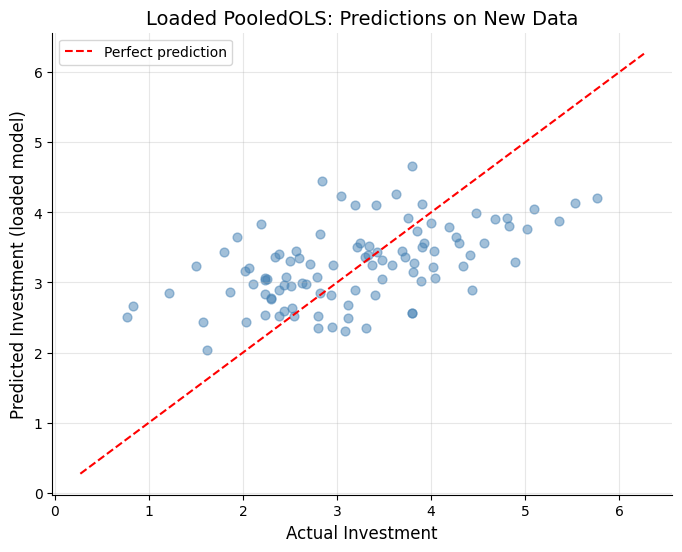

Figure saved to ../outputs/figures/02_loaded_ols_predictions.png


In [9]:
# Visualize: loaded model predictions vs actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_new_firms["investment"], preds_loaded, alpha=0.5, s=40, color="steelblue")
lims = [
    min(df_new_firms["investment"].min(), preds_loaded.min()) - 0.5,
    max(df_new_firms["investment"].max(), preds_loaded.max()) + 0.5,
]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Investment")
ax.set_ylabel("Predicted Investment (loaded model)")
ax.set_title("Loaded PooledOLS: Predictions on New Data")
ax.legend()
fig.savefig(FIGURES_DIR / "02_loaded_ols_predictions.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to {FIGURES_DIR / '02_loaded_ols_predictions.png'}")

---
## 3. GMMResults — Save & Load

GMM results carry much more metadata than static models: diagnostic tests (Hansen J, AR tests), instrument counts, transformation type, and dynamic prediction capabilities. Let's verify all of this survives save/load.

In [10]:
# Estimate Difference GMM
model_gmm = DifferenceGMM(
    data=df_lgd,
    dep_var="lgd_logit",
    lags=1,
    exog_vars=["saldo_real", "pib_growth", "selic", "collateral_ratio"],
    id_var="contract_id",
    time_var="month",
    collapse=True,
    time_dummies=False,
)
results_gmm = model_gmm.fit()
print(results_gmm.summary())

                                Difference GMM                                
Number of observations:          2,600
Number of groups:                  200
Number of instruments:              16
Instrument ratio:                0.080
GMM type:                   Two-step (Windmeijer)
------------------------------------------------------------------------------
Variable                    Coef.     Std.Err.        z    P>|z|     [95% Conf. Int.]
------------------------------------------------------------------------------
L1.lgd_logit             0.614237     0.018734    32.79   0.0000 [ 0.577519,  0.650954] ***
saldo_real               0.101374     0.025838     3.92   0.0001 [ 0.050733,  0.152015] ***
pib_growth               0.050047     0.003041    16.46   0.0000 [ 0.044087,  0.056007] ***
selic                    0.001352     0.012880     0.10   0.9164 [-0.023893,  0.026596] 
collateral_ratio         0.194452     0.148108     1.31   0.1892 [-0.095834,  0.484738] 
Specification Tes

In [11]:
# Save GMM results
gmm_pkl_path = MODELS_DIR / "gmm_lgd.pkl"
results_gmm.save(str(gmm_pkl_path))

file_size = gmm_pkl_path.stat().st_size
print(f"Saved to: {gmm_pkl_path}")
print(f"File size: {file_size:,} bytes ({file_size / 1024:.1f} KB)")

Saved to: ../outputs/models/gmm_lgd.pkl
File size: 26,219 bytes (25.6 KB)


In [12]:
# Load GMM results
loaded_gmm = GMMResults.load(str(gmm_pkl_path))

print(f"Type: {type(loaded_gmm).__name__}")
print(f"Model type: {loaded_gmm.model_type}")
print(f"Dep var: {loaded_gmm.dep_var}")
print(f"Exog vars: {loaded_gmm.exog_vars}")
print(f"N lags: {loaded_gmm.n_lags}")
print(f"Observations: {loaded_gmm.nobs}")
print(f"Groups: {loaded_gmm.n_groups}")
print(f"Instruments: {loaded_gmm.n_instruments}")

Type: GMMResults
Model type: difference
Dep var: lgd_logit
Exog vars: ['saldo_real', 'pib_growth', 'selic', 'collateral_ratio']
N lags: 1
Observations: 2600
Groups: 200
Instruments: 16


In [13]:
# Verify diagnostic tests are preserved
print("Diagnostic test comparison:")
print(f"{'Test':<20} {'Original':>12} {'Loaded':>12} {'Match?':>8}")
print("-" * 55)

tests = [
    ("Hansen J stat", results_gmm.hansen_j.statistic, loaded_gmm.hansen_j.statistic),
    ("Hansen J p-val", results_gmm.hansen_j.pvalue, loaded_gmm.hansen_j.pvalue),
    ("AR(1) stat", results_gmm.ar1_test.statistic, loaded_gmm.ar1_test.statistic),
    ("AR(1) p-val", results_gmm.ar1_test.pvalue, loaded_gmm.ar1_test.pvalue),
    ("AR(2) stat", results_gmm.ar2_test.statistic, loaded_gmm.ar2_test.statistic),
    ("AR(2) p-val", results_gmm.ar2_test.pvalue, loaded_gmm.ar2_test.pvalue),
]

for name, orig, load in tests:
    match = np.isclose(orig, load)
    print(f"{name:<20} {orig:>12.4f} {load:>12.4f} {'YES' if match else 'NO':>8}")

print()
print("All diagnostic tests preserved.")

Diagnostic test comparison:
Test                     Original       Loaded   Match?
-------------------------------------------------------
Hansen J stat             16.5504      16.5504      YES
Hansen J p-val             0.1219       0.1219      YES
AR(1) stat               -21.5147     -21.5147      YES
AR(1) p-val                0.0000       0.0000      YES
AR(2) stat                -0.4666      -0.4666      YES
AR(2) p-val                0.6408       0.6408      YES

All diagnostic tests preserved.


In [14]:
# Verify predict works on loaded GMM model
preds_gmm_orig = results_gmm.predict(df_new_bank)
preds_gmm_loaded = loaded_gmm.predict(df_new_bank)

valid = ~np.isnan(preds_gmm_orig)
print(f"Total predictions: {len(preds_gmm_loaded)}")
print(f"Valid (non-NaN):   {valid.sum()}")
print(f"Max absolute diff: {np.nanmax(np.abs(preds_gmm_orig - preds_gmm_loaded)):.2e}")
print()

assert np.allclose(preds_gmm_orig[valid], preds_gmm_loaded[valid]), "GMM predictions mismatch!"
print("GMM predictions are identical after save/load.")

Total predictions: 150
Valid (non-NaN):   100
Max absolute diff: 0.00e+00

GMM predictions are identical after save/load.


---
## 4. Universal `load_model()`

In production, you may not know which model type a pickle file contains. The `load_model()` function handles this automatically — it works with **any** PanelBox results class.

```python
from panelbox import load_model

# Works with any pickle file created by PanelBox
result = load_model('some_model.pkl')  # auto-detects type
```

In [15]:
# Load the OLS model using the universal loader
result_ols = load_model(str(pkl_path))
print(f"Loaded type: {type(result_ols).__name__}")
print(f"Model: {result_ols.model_type}")
print(f"R-squared: {result_ols.rsquared:.4f}")
print()

Loaded type: PanelResults
Model: Pooled OLS
R-squared: 0.3273



In [16]:
# Load the GMM model using the universal loader
result_gmm = load_model(str(gmm_pkl_path))
print(f"Loaded type: {type(result_gmm).__name__}")
print(f"Model: {result_gmm.model_type}")
print(f"Hansen J p-value: {result_gmm.hansen_j.pvalue:.4f}")
print(f"Instrument ratio: {result_gmm.instrument_ratio:.3f}")

Loaded type: GMMResults
Model: difference
Hansen J p-value: 0.1219
Instrument ratio: 0.080


In [17]:
# Both loaded models can predict
pred_ols = result_ols.predict(df_new_firms)
pred_gmm = result_gmm.predict(df_new_bank)

print(f"OLS predictions:  {len(pred_ols)} values, mean={pred_ols.mean():.4f}")
print(
    f"GMM predictions:  {len(pred_gmm)} values ({(~np.isnan(pred_gmm)).sum()} valid), mean={np.nanmean(pred_gmm):.4f}"
)
print()
print("load_model() is the simplest way to load any PanelBox model in production.")

OLS predictions:  100 values, mean=3.2442
GMM predictions:  150 values (100 valid), mean=1.4844

load_model() is the simplest way to load any PanelBox model in production.


### When to use which loader?

| Method | Use case |
|--------|----------|
| `PanelResults.load(path)` | You know it's a static model (OLS, FE, RE) |
| `GMMResults.load(path)` | You know it's a GMM model |
| `load_model(path)` | You don't know the type, or want a generic loader |

---
## 5. Exporting Coefficients

Sometimes you need to extract model coefficients for use outside Python — in a SQL query, an R script, a spreadsheet, or an API. PanelBox provides two export methods:

- **`to_dict()`** — Python dictionary for programmatic use
- **`to_json()`** — JSON string/file for APIs and external systems

### 5.1 `to_dict()` — Python Dictionary

In [18]:
# Export PanelResults as dict
ols_dict = results_ols.to_dict()

print("Top-level keys:")
for key in ols_dict:
    val = ols_dict[key]
    if isinstance(val, dict):
        print(f"  {key}: dict with {len(val)} entries")
    elif isinstance(val, list):
        print(f"  {key}: list with {len(val)} elements")
    else:
        print(f"  {key}: {type(val).__name__}")

Top-level keys:
  params: dict with 4 entries
  std_errors: dict with 4 entries
  tvalues: dict with 4 entries
  pvalues: dict with 4 entries
  cov_params: dict with 3 entries
  resid: list with 2000 elements
  fittedvalues: list with 2000 elements
  model_info: dict with 4 entries
  sample_info: dict with 5 entries
  rsquared: dict with 5 entries


In [19]:
# Access specific components
print("Coefficients:")
for name, coef in ols_dict["params"].items():
    se = ols_dict["std_errors"][name]
    pval = ols_dict["pvalues"][name]
    print(f"  {name:>15}: {coef:>10.6f}  (SE={se:.6f}, p={pval:.4f})")

print()
print("Model info:", ols_dict["model_info"])
print("Sample info:", ols_dict["sample_info"])

Coefficients:
        Intercept:  -0.507405  (SE=0.136995, p=0.0002)
            value:   0.299045  (SE=0.012883, p=0.0000)
          capital:   0.277294  (SE=0.021804, p=0.0000)
            sales:   0.167421  (SE=0.010467, p=0.0000)

Model info: {'model_type': 'Pooled OLS', 'formula': 'investment ~ value + capital + sales', 'cov_type': 'nonrobust', 'cov_kwds': {}}
Sample info: {'nobs': 2000, 'n_entities': 100, 'n_periods': 20, 'df_model': 3, 'df_resid': 1996}


In [20]:
# GMM to_dict() includes diagnostic tests
gmm_dict = results_gmm.to_dict()

print("GMM dict keys:", list(gmm_dict.keys()))
print()
print("Hansen J test:", gmm_dict["hansen_j"])
print("AR(2) test:", gmm_dict["ar2_test"])
print(f"Instrument ratio: {gmm_dict['instrument_ratio']:.3f}")

GMM dict keys: ['params', 'std_errors', 'pvalues', 'nobs', 'n_groups', 'n_instruments', 'hansen_j', 'sargan', 'ar1_test', 'ar2_test', 'instrument_ratio', 'converged']

Hansen J test: {'name': 'Hansen J-test', 'statistic': 16.55044870976506, 'pvalue': 0.12189433368252178, 'df': 11, 'conclusion': 'PASS'}
AR(2) test: {'name': 'AR(2) test', 'statistic': np.float64(-0.46662482159691443), 'pvalue': np.float64(0.6407683250399918), 'df': None, 'conclusion': 'PASS'}
Instrument ratio: 0.080


### 5.2 `to_json()` — JSON Export

In [21]:
# Export to JSON file
json_export_path = MODELS_DIR / "coefficients_ols.json"
json_str = results_ols.to_json(str(json_export_path))

print(f"JSON exported to: {json_export_path}")
print(f"JSON string length: {len(json_str):,} characters")
print()
print("First 500 characters:")
print(json_str[:500])

JSON exported to: ../outputs/models/coefficients_ols.json
JSON string length: 98,194 characters

First 500 characters:
{
  "params": {
    "Intercept": -0.5074050147613818,
    "value": 0.2990451388362428,
    "capital": 0.2772938152703679,
    "sales": 0.1674205188052195
  },
  "std_errors": {
    "Intercept": 0.13699516337853299,
    "value": 0.012882799859334174,
    "capital": 0.02180354590600603,
    "sales": 0.010467236041667735
  },
  "tvalues": {
    "Intercept": -3.7038169979721465,
    "value": 23.212744287071338,
    "capital": 12.717831148463985,
    "sales": 15.994720873662894
  },
  "pvalues": {
  


In [22]:
# Get JSON string without saving to file
json_str_only = results_ols.to_json()
parsed = json.loads(json_str_only)

print("Parsed JSON params:", parsed["params"])
print()
print("This JSON can be sent to an API, stored in a database, or loaded in any language.")

Parsed JSON params: {'Intercept': -0.5074050147613818, 'value': 0.2990451388362428, 'capital': 0.2772938152703679, 'sales': 0.1674205188052195}

This JSON can be sent to an API, stored in a database, or loaded in any language.


### 5.3 Manual Extraction for External Systems

Sometimes you need to deploy model coefficients in a system that can't run Python. Here's how to extract a scoring formula.

In [23]:
# Generate SQL scoring formula
print("=== SQL Scoring Formula ===")
print()

intercept = None
terms = []
for name, coef in results_ols.params.items():
    if name.lower() == "intercept":
        intercept = coef
    else:
        terms.append(f"{coef:.6f} * {name}")

formula_parts = []
if intercept is not None:
    formula_parts.append(f"{intercept:.6f}")
formula_parts.extend(terms)

sql = f"SELECT {' + '.join(formula_parts)} AS predicted_investment\nFROM firms;"
print(sql)

=== SQL Scoring Formula ===

SELECT -0.507405 + 0.299045 * value + 0.277294 * capital + 0.167421 * sales AS predicted_investment
FROM firms;


In [24]:
# Generate R formula
print("=== R Code ===")
print()
print("# Coefficients from PanelBox PooledOLS")
print("coefs <- c(")
items = list(results_ols.params.items())
for i, (name, coef) in enumerate(items):
    comma = "," if i < len(items) - 1 else ""
    r_name = name.lower().replace(" ", "_")
    print(f"  {r_name} = {coef:.6f}{comma}")
print(")")
print()
print("# Predict")
print(
    'predicted <- coefs["intercept"] + coefs["value"] * df$value + coefs["capital"] * df$capital + coefs["sales"] * df$sales'
)

=== R Code ===

# Coefficients from PanelBox PooledOLS
coefs <- c(
  intercept = -0.507405,
  value = 0.299045,
  capital = 0.277294,
  sales = 0.167421
)

# Predict
predicted <- coefs["intercept"] + coefs["value"] * df$value + coefs["capital"] * df$capital + coefs["sales"] * df$sales


---
## 6. Pickle vs JSON — Trade-offs

| Feature | Pickle | JSON |
|---------|--------|------|
| **Preserves everything** | Yes (all objects, methods) | No (coefficients & metadata only) |
| **`predict()` works** | Yes | No (can't load back as object) |
| **Human-readable** | No (binary) | Yes (text) |
| **Cross-language** | Python only | Any language |
| **Security** | Risk: can execute arbitrary code | Safe: just data |
| **File size** | Larger | Smaller |
| **Use case** | Production deployment | Sharing coefficients, documentation, APIs |

In [25]:
# Compare file sizes
pkl_size = (MODELS_DIR / "pooled_ols_v1.pkl").stat().st_size
json_size = (MODELS_DIR / "pooled_ols_v1.json").stat().st_size
gmm_size = (MODELS_DIR / "gmm_lgd.pkl").stat().st_size

size_data = pd.DataFrame(
    {
        "Model": ["PooledOLS (pickle)", "PooledOLS (JSON)", "GMM (pickle)"],
        "Size (bytes)": [pkl_size, json_size, gmm_size],
        "Size (KB)": [pkl_size / 1024, json_size / 1024, gmm_size / 1024],
    }
)
print(size_data.to_string(index=False))

             Model  Size (bytes)  Size (KB)
PooledOLS (pickle)        254752 248.781250
  PooledOLS (JSON)         98194  95.892578
      GMM (pickle)         26219  25.604492

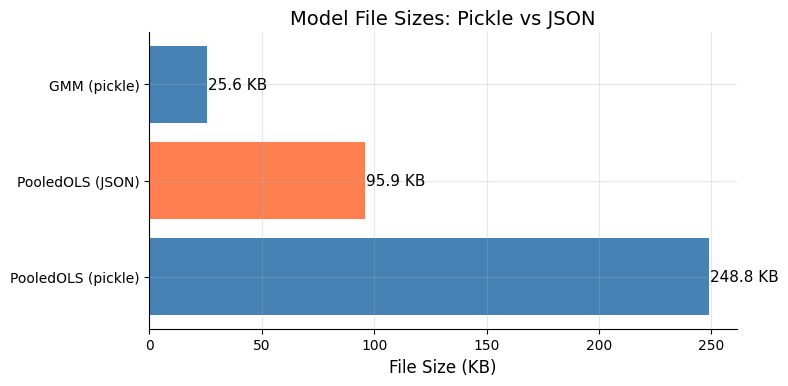

Figure saved to ../outputs/figures/02_file_sizes.png


In [26]:
# Visualize file sizes
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue", "coral", "steelblue"]
bars = ax.barh(size_data["Model"], size_data["Size (KB)"], color=colors)
ax.set_xlabel("File Size (KB)")
ax.set_title("Model File Sizes: Pickle vs JSON")
for bar, val in zip(bars, size_data["Size (KB)"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{val:.1f} KB", va="center")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_file_sizes.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to {FIGURES_DIR / '02_file_sizes.png'}")

### Best Practices

1. **Always use pickle for production** — it preserves everything, including `predict()`
2. **Use JSON for sharing coefficients** — documentation, APIs, external systems
3. **Include metadata** alongside the pickle — version, date, who trained it
4. **Never unpickle untrusted files** — pickle can execute arbitrary code. Only load files you or your team created
5. **Version your models** — use the `ModelRegistry` (covered in Notebook 04) or manual naming conventions (e.g., `model_v1.pkl`, `model_v2.pkl`)

---
## Summary

| Method | What it does | When to use |
|--------|-------------|-------------|
| `results.save('file.pkl')` | Save full object as pickle | Production deployment |
| `results.save('file.json', format='json')` | Save as JSON | Sharing, documentation |
| `PanelResults.load('file.pkl')` | Load static model results | When you know the type |
| `GMMResults.load('file.pkl')` | Load GMM results | When you know it's GMM |
| `load_model('file.pkl')` | Universal loader | Generic production code |
| `results.to_dict()` | Export as Python dict | Programmatic access |
| `results.to_json()` | Export as JSON string/file | APIs, external systems |

**Key takeaways**:
- Pickle preserves everything (coefficients, diagnostics, predict capability)
- JSON is human-readable but limited (no predict, no object methods)
- `load_model()` is the simplest way to load any PanelBox model
- Always verify loaded models produce identical predictions

---
## Exercises

### Exercise 1 (Easy): Save & Load a Fixed Effects Model

1. Estimate a `FixedEffects` model on `df_firms` with `entity_effects=True`
2. Save it to `outputs/models/fe_model.pkl`
3. Load it back using `load_model()`
4. Verify that entity fixed effects are preserved by checking `model.entity_fe`

**Hint**: Access the underlying model object via `results._model` or check if `results._entity_fe` exists on the loaded object.

In [27]:
# YOUR CODE HERE


### Exercise 2 (Medium): Save Isolation Test

Demonstrate that saving creates an **independent copy**:

1. Save `results_ols` to a pickle file
2. Modify the original `results_ols.params` (e.g., set all coefficients to 0)
3. Load the saved file
4. Verify the loaded model has the **original** (unmodified) coefficients

This proves that `save()` creates a snapshot that is independent of the original object.

In [28]:
# YOUR CODE HERE


### Exercise 3 (Medium): Export Model Card

Create a function `export_model_card(results, filepath)` that saves a JSON file with:

- Model name/type
- Coefficients (names and values)
- Training info (nobs, n_entities, n_periods)
- Goodness of fit (R-squared or equivalent)
- Export timestamp

Test it with both `results_ols` and `results_gmm`.

In [29]:
# YOUR CODE HERE


---
*Solutions are available in `../solutions/02_save_load_solutions.ipynb`*